# Análisis de señales de camino

In [60]:
import os
import random
import shutil
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import models
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("GPU configurada correctamente")
else:
    print("No se detectó GPU")

GPU configurada correctamente


## Limpiar output

In [61]:
rm -r /kaggle/working

rm: cannot remove '/kaggle/working': Device or resource busy


## Importar el data set

Usando la forma de descarga que viene en Kaggle

In [62]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ziadghanem01/road-signs")

path += "/dataset"
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ziadghanem01/road-signs/dataset


Dentro de la ruta existen las carpetas ya separadas en Test y Training

In [63]:
!ls -l /kaggle/input/datasets/ziadghanem01/road-signs/dataset

total 0
drwxr-xr-x 9 nobody nogroup 0 Jun  8 20:54 train
drwxr-xr-x 9 nobody nogroup 0 Jun  8 20:54 val


Y dentro de cada una estan las categorias:
- Keep Left
- Keep Right
- No entry
- Pedestrian Crossing
- Stop Sign
- Turn Left
- Turn Right

In [64]:
!ls -l /kaggle/input/datasets/ziadghanem01/road-signs/dataset/train

total 0
drwxr-xr-x 2 nobody nogroup 0 Jun  8 20:54 'Keep Left'
drwxr-xr-x 2 nobody nogroup 0 Jun  8 20:54 'Keep Right'
drwxr-xr-x 2 nobody nogroup 0 Jun  8 20:54 'No Entry'
drwxr-xr-x 2 nobody nogroup 0 Jun  8 20:54 'Pedestrian Crossing'
drwxr-xr-x 2 nobody nogroup 0 Jun  8 20:54 'Stop Sign'
drwxr-xr-x 2 nobody nogroup 0 Jun  8 20:54 'Turn Left'
drwxr-xr-x 2 nobody nogroup 0 Jun  8 20:54 'Turn Right'


Exploramos la estructura el dataset, para conocer el tamaño de cada clase y a su vez combinamos todas las carpetas para generar un dataset y posteriormente separa la estructura en train, test y val.

In [65]:
train_dir = path + '/train'
val_dir = path + '/val'
all_coins_path = '/kaggle/working/all_signals'

# Crear carpeta principal
os.makedirs(all_coins_path, exist_ok=True)

# Lista de clases
classes = [
    'Keep Left',
    'Keep Right',
    'No Entry',
    'Pedestrian Crossing',
    'Stop Sign',
    'Turn Left',
    'Turn Right'
]

for cls in classes:
    # Crear carpeta de la clase en all_signals
    dest_class_dir = os.path.join(all_coins_path, cls)
    os.makedirs(dest_class_dir, exist_ok=True)

    count = 0

    # Copiar desde TRAIN
    train_class_dir = os.path.join(train_dir, cls)
    if os.path.exists(train_class_dir):
        for img in os.listdir(train_class_dir):
            src = os.path.join(train_class_dir, img)
            dst = os.path.join(dest_class_dir, img)
            shutil.copy(src, dst)
            count += 1

    # Copiar desde VAL
    val_class_dir = os.path.join(val_dir, cls)
    if os.path.exists(val_class_dir):
        for img in os.listdir(val_class_dir):
            src = os.path.join(val_class_dir, img)
            dst = os.path.join(dest_class_dir, img)
            # Si existe el mismo nombre, agregar prefijo "val_"
            if os.path.exists(dst):
                name, ext = os.path.splitext(img)
                dst = os.path.join(dest_class_dir, f"{name}_val{ext}")
            shutil.copy(src, dst)
            count += 1

    print(f"{cls}: {count} imágenes combinadas")


Keep Left: 303 imágenes combinadas
Keep Right: 667 imágenes combinadas
No Entry: 634 imágenes combinadas
Pedestrian Crossing: 251 imágenes combinadas
Stop Sign: 119 imágenes combinadas
Turn Left: 443 imágenes combinadas
Turn Right: 552 imágenes combinadas


## Nivelar las imagenes por carpeta

Para este caso las nivelare todas a las de menor cantidad 119

## Nivelación Segmentación

Para este caso las nivelare todas a las clases al de menor cantidad, el cual es 119. Esto con el fin de evitar el "sesgo del modelo", ya que el modelo puede aprende mucho mejor la clase que tiene más imagenes.

Y también separare las imagenes en:
- Test: 20%
- Entrenamiento: 70%
- Validación: 10%

Y alterare el orden del data set para evitar que el modelo tome las imagenes de un solo tipo evitando que el modelo aprenda patrones falsos sobre las categorias.

In [66]:
output_dataset_path = "/kaggle/working/signals"

# Balancear todas las clases
images_per_class = 119

# Porcentajes
train_ratio = 0.70
val_ratio = 0.10
test_ratio = 0.20

def create_folders(path, output_dataset_path):
    for split in ['train', 'val', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(output_dataset_path, split, cls), exist_ok=True)

def split_dataset(path, output_dataset_path):
    # Crear carpetas
    create_folders(path, output_dataset_path)

    # Recorrer carpetas
    for cls in classes:
        class_path = os.path.join(path, cls)
        if not os.path.exists(class_path):
            print(f"Carpeta no encontrada: {cls}")
            continue

        images = []
        for f in os.listdir(class_path):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                images.append(f)

        # Balancear a 306 imágenes
        random.seed(42)
        images = random.sample(images, images_per_class)

        # Barajar
        random.seed(42)
        random.shuffle(images)

        n_images = len(images)

        # Calcular cantidad por split
        train_end = int(n_images * train_ratio)
        val_end = train_end + int(n_images * val_ratio)

        partitions = {
            'train': images[:train_end],
            'val': images[train_end:val_end],
            'test': images[val_end:]
        }

        # Copiar archivos
        for split_name, file_list in partitions.items():
            for f in file_list:
                src = os.path.join(class_path, f)
                dst = os.path.join(output_dataset_path, split_name, cls, f)
                shutil.copy(src, dst)


In [67]:
split_dataset(all_coins_path, output_dataset_path)

def count_split(output_dataset_path):
    for split in ['train', 'val', 'test']:
        print(f"\n=== {split.upper()} ===")
        for cls in classes:
            path = os.path.join(output_dataset_path, split, cls)
            count = len(os.listdir(path))
            print(f"{cls}: {count} imágenes")

count_split(output_dataset_path)


=== TRAIN ===
Keep Left: 83 imágenes
Keep Right: 83 imágenes
No Entry: 83 imágenes
Pedestrian Crossing: 83 imágenes
Stop Sign: 83 imágenes
Turn Left: 83 imágenes
Turn Right: 83 imágenes

=== VAL ===
Keep Left: 11 imágenes
Keep Right: 11 imágenes
No Entry: 11 imágenes
Pedestrian Crossing: 11 imágenes
Stop Sign: 11 imágenes
Turn Left: 11 imágenes
Turn Right: 11 imágenes

=== TEST ===
Keep Left: 25 imágenes
Keep Right: 25 imágenes
No Entry: 25 imágenes
Pedestrian Crossing: 25 imágenes
Stop Sign: 25 imágenes
Turn Left: 25 imágenes
Turn Right: 25 imágenes


## Data Augmentation

Debido a que tengo alrededor de 119 imagenes (un dataset pequeño), realizare un aumento de imagenes.

In [68]:
# Configuración de Data Augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=False,
)

# El set de validación y test solo se escala, no se aumenta
val_datagen = ImageDataGenerator(rescale=1./255)

# Generadores de flujo de datos
train_generator = train_datagen.flow_from_directory(
    os.path.join(output_dataset_path, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(output_dataset_path, 'val'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    os.path.join(output_dataset_path, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 581 images belonging to 7 classes.
Found 77 images belonging to 7 classes.
Found 175 images belonging to 7 classes.


## Creación del modelo

In [69]:
def get_model(input_shape):

    model = Sequential([
      Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
      MaxPooling2D((2, 2)),

      Conv2D(64, (3, 3), activation='relu'),
      MaxPooling2D((2, 2)),

      Conv2D(128, (3, 3), activation='relu'),
      MaxPooling2D((2, 2)),

      Flatten(),
      Dense(512, activation='relu'),
      Dense(7, activation='softmax')
    ])

    return model

In [70]:
images, labels = next(train_generator)
input_shape = images[0].shape
model = get_model(input_shape)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,399,687 (169.37 MB)

 Trainable params: 44,399,687 (169.37 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
def compile_model(model):
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 'F1Score'])

compile_model(model)

In [72]:
def train_model(model, train_generator, validation_generator, epochs):
    history = model.fit(
        train_generator,
        steps_per_epoch=100,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=50,
    )
    return history

trained_model = train_model(model, train_generator, validation_generator, epochs=30)

Epoch 1/30
 19/100 ━━━━━━━━━━━━━━━━━━━━ 28s 356ms/step - F1Score: 0.1492 - accuracy: 0.1734 - loss: 2.5457

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - F1Score: 0.2096 - accuracy: 0.2238 - loss: 2.0625 - val_F1Score: 0.4927 - val_accuracy: 0.5455 - val_loss: 1.3581
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - F1Score: 0.4526 - accuracy: 0.4561 - loss: 1.3030 - val_F1Score: 0.5532 - val_accuracy: 0.6234 - val_loss: 1.0485
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - F1Score: 0.5366 - accuracy: 0.5387 - loss: 1.0773 - val_F1Score: 0.5173 - val_accuracy: 0.5974 - val_loss: 0.9774
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - F1Score: 0.5735 - accuracy: 0.5766 - loss: 0.9992 - val_F1Score: 0.7254 - val_accuracy: 0.7403 - val_loss: 0.6684
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - F1Score: 0.6367 - accuracy: 0.6403 - loss: 0.8620 - val_F1Score: 0.6672 - val_accuracy: 0.7013 - val_loss: 0.6746
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - F1Score: 0.6900 - accuracy: 0.6919 - loss: 0.7852 - val_F1Score: 0.8245 - val_accuracy: 0.8312 - val_loss: 0.5

## Graficar validation contra training

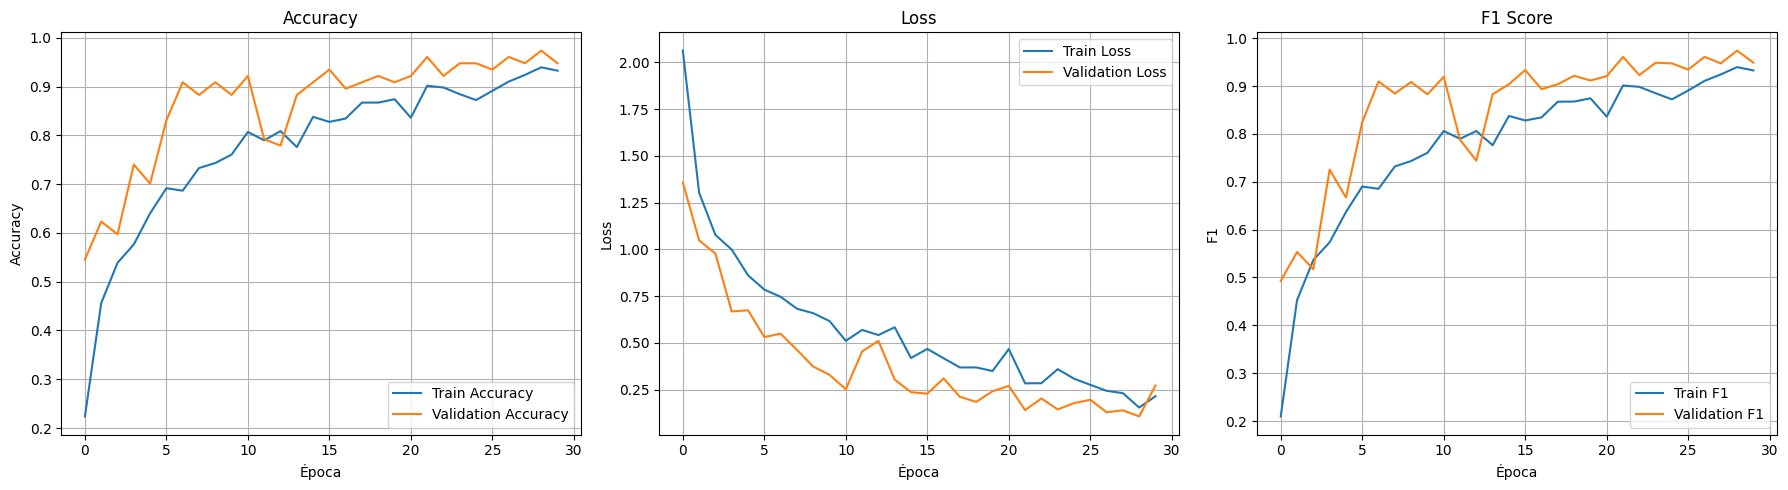

In [73]:
def plot_training_history(history):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Gráfica de Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Gráfica de Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    # Gráfica de F1
    train_f1 = np.mean(history.history['F1Score'], axis=1)
    val_f1 = np.mean(history.history['val_F1Score'], axis=1)
    
    axes[2].plot(train_f1, label='Train F1')
    axes[2].plot(val_f1, label='Validation F1')
    axes[2].set_title('F1 Score')
    axes[2].set_xlabel('Época')
    axes[2].set_ylabel('F1')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(trained_model)

## Evaluar el modelo

In [74]:
test_loss, test_accuracy, test_f1 = model.evaluate(test_generator)

test_f1_mean = np.mean(test_f1)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test F1-score: {test_f1_mean:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - F1Score: 0.9344 - accuracy: 0.9371 - loss: 0.1900
Test loss: 0.1900
Test accuracy: 0.9371
Test F1-score: 0.9344


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


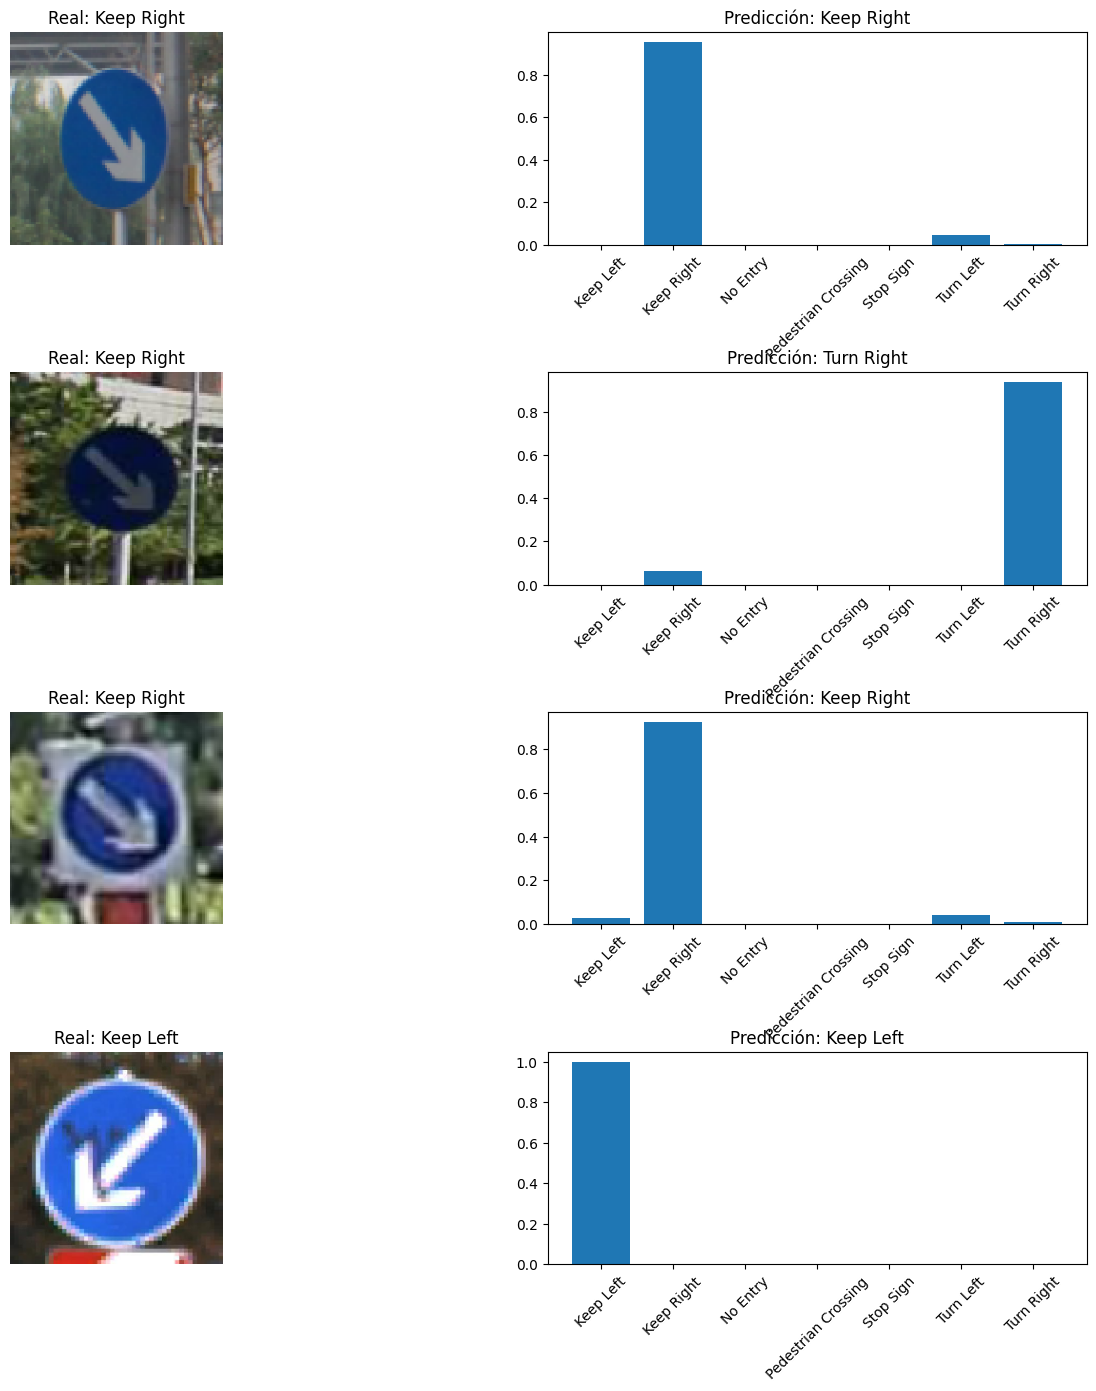

In [75]:
def show_predictions(modelo, generador, n_samples=4):
    test_images, test_labels_batch = next(generador)
    
    # Asegurar que no pidamos más muestras de las que tiene el lote
    n_samples = min(n_samples, test_images.shape[0])
    random_inx = np.random.choice(test_images.shape[0], n_samples, replace=False)
    
    sample_images = test_images[random_inx]
    sample_labels = test_labels_batch[random_inx]
    
    # 2. Realizar la predicción
    predictions = modelo.predict(sample_images)
    
    # 3. Mapeo de índices a nombres
    class_names = list(generador.class_indices.keys())
    
    # 4. Configurar el gráfico
    fig, axes = plt.subplots(n_samples, 2, figsize=(16, 4 * n_samples))
    fig.subplots_adjust(hspace=0.6, wspace=0.3)
    
    # Manejar caso de n_samples = 1 donde axes no es una matriz
    if n_samples == 1:
        axes = np.array([axes])

    for i in range(n_samples):
        img = sample_images[i]
        label = sample_labels[i]
        pred = predictions[i]
        
        # Mostrar imagen
        axes[i, 0].imshow(img)
        axes[i, 0].axis('off')
        actual_cls = class_names[np.argmax(label)]
        axes[i, 0].set_title(f'Real: {actual_cls}')
    
        # Mostrar gráfico de barras de predicciones
        axes[i, 1].bar(class_names, pred)
        axes[i, 1].set_xticks(range(len(class_names)))
        axes[i, 1].set_xticklabels(class_names, rotation=45)
        pred_cls = class_names[np.argmax(pred)]
        axes[i, 1].set_title(f'Predicción: {pred_cls}')

    plt.show()   


show_predictions(model, test_generator)

In [76]:
!ls -l /kaggle/input/datasets/axelcv10/myroadsignalsdataset

total 308
-rw-r--r-- 1 nobody nogroup 22557 Jun  8 20:54 Keep_Left1.png
-rw-r--r-- 1 nobody nogroup  6704 Jun  8 20:54 Keep_Left.png
-rw-r--r-- 1 nobody nogroup 21805 Jun  8 20:54 Keep_Right1.png
-rw-r--r-- 1 nobody nogroup  7019 Jun  8 20:54 Keep_Right.png
-rw-r--r-- 1 nobody nogroup 13933 Jun  8 20:54 No_entry1.png
-rw-r--r-- 1 nobody nogroup 20240 Jun  8 20:54 No_entry.png
-rw-r--r-- 1 nobody nogroup 17843 Jun  8 20:54 Pedestrian_crossing1.png
-rw-r--r-- 1 nobody nogroup 21912 Jun  8 20:54 Pedestrian_crossing.png
-rw-r--r-- 1 nobody nogroup 60536 Jun  8 20:54 Stop1.png
-rw-r--r-- 1 nobody nogroup 28794 Jun  8 20:54 Stop.png
-rw-r--r-- 1 nobody nogroup 10245 Jun  8 20:54 Turn_Left1.png
-rw-r--r-- 1 nobody nogroup 22779 Jun  8 20:54 Turn_Left.png
-rw-r--r-- 1 nobody nogroup 10209 Jun  8 20:54 Turn_Right1.png
-rw-r--r-- 1 nobody nogroup 22952 Jun  8 20:54 Turn_Right.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step


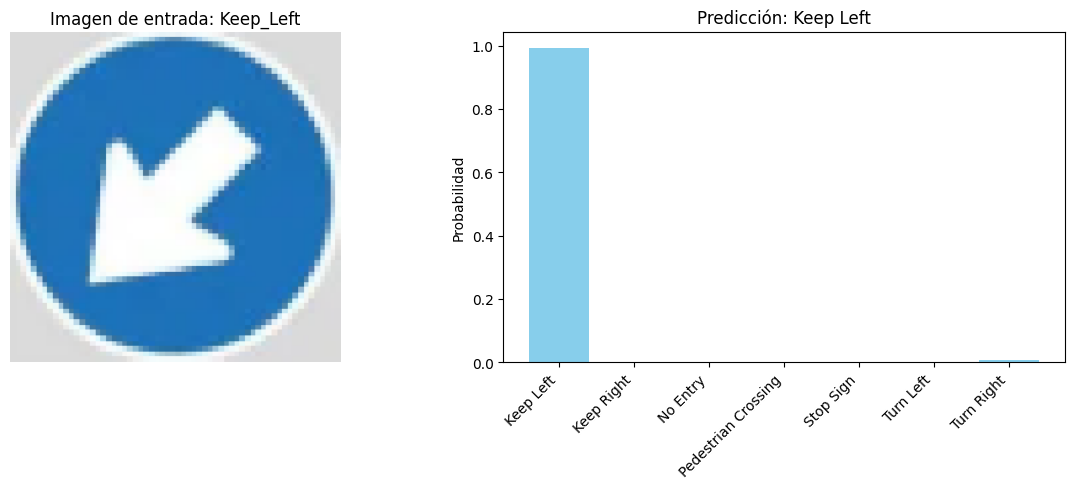

In [77]:
from tensorflow.keras.preprocessing import image

img_path = '/kaggle/input/datasets/axelcv10/myroadsignalsdataset/Keep_Left.png'
img = image.load_img(img_path, target_size=(224, 224))

x = image.img_to_array(img)
x = x / 255.0

x = np.expand_dims(x, axis=0)

predictions = model.predict(x)
class_names = list(test_generator.class_indices.keys())
pred_label = class_names[np.argmax(predictions)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title('Imagen de entrada: Keep_Left')

y_pos = np.arange(len(class_names))
axes[1].bar(y_pos, predictions[0], color='skyblue')
axes[1].set_xticks(y_pos)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_title(f'Predicción: {pred_label}')
axes[1].set_ylabel('Probabilidad')

plt.tight_layout()
plt.show()

## Guardar el modelo


In [78]:
model.save('/kaggle/working/road_signs_model.h5')

# Arquitectura del paper

In [79]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Cargar el modelo base pre-entrenado (VGG-16) usando los pesos de ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelar las capas del modelo base para que actúen solo como extractor de características
for layer in base_model.layers:
    layer.trainable = False

# Añadir la nueva capa de clasificación
x = base_model.output
x = Flatten()(x)
# Se añade una capa densa (Fully Connected) como indica el paper
x = Dense(512, activation='relu')(x) 
# Capa de salida ajustada a a las 7 clases de señales de tránsito
predictions = Dense(7, activation='softmax')(x)

# Construir el modelo uniendo la base y la nueva salida
paper_model = Model(inputs=base_model.input, outputs=predictions)

# Compilar usando la tasa de aprendizaje exacta del paper (1e-5)
paper_model.compile(optimizer=Adam(learning_rate=1e-5),
                    loss='categorical_crossentropy',
                    metrics=['accuracy', 'F1Score'])

paper_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,563,847 (105.15 MB)

 Trainable params: 12,849,159 (49.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [80]:
# Definir Early Stopping con paciencia de 3 épocas
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

# Entrenar el modelo con un máximo de 15 épocas
paper_history = paper_model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=15,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    callbacks=[early_stop]
)

Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 478ms/step - F1Score: 0.2054 - accuracy: 0.2022 - loss: 1.9708 - val_F1Score: 0.3793 - val_accuracy: 0.4219 - val_loss: 1.7251
Epoch 2/15
 1/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - F1Score: 0.2553 - accuracy: 0.2500 - loss: 1.7932

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - F1Score: 0.2553 - accuracy: 0.2500 - loss: 1.7932 - val_F1Score: 0.3709 - val_accuracy: 0.4219 - val_loss: 1.7260
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 367ms/step - F1Score: 0.4327 - accuracy: 0.4481 - loss: 1.6488 - val_F1Score: 0.4203 - val_accuracy: 0.4688 - val_loss: 1.4803
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - F1Score: 0.5195 - accuracy: 0.5625 - loss: 1.5058 - val_F1Score: 0.4789 - val_accuracy: 0.5000 - val_loss: 1.4856
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 361ms/step - F1Score: 0.5963 - accuracy: 0.6084 - loss: 1.4411 - val_F1Score: 0.6584 - val_accuracy: 0.6562 - val_loss: 1.2737
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - F1Score: 0.5167 - accuracy: 0.5312 - loss: 1.4962 - val_F1Score: 0.6188 - val_accuracy: 0.6094 - val_loss: 1.3146
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 361ms/step - F1Score: 0.6207 - accuracy: 0.6175 - loss: 1.3066 - val_F1Score: 0.6924 - val_accuracy: 0.6875 - val_loss: 1.1639
Epoch 

## Evaluar el modelo

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - F1Score: 0.7618 - accuracy: 0.7543 - loss: 0.8422
Resultados del Modelo Paper (VGG-16):
Test Loss: 0.8422
Test Accuracy: 0.7543
Test F1 score: 0.7618


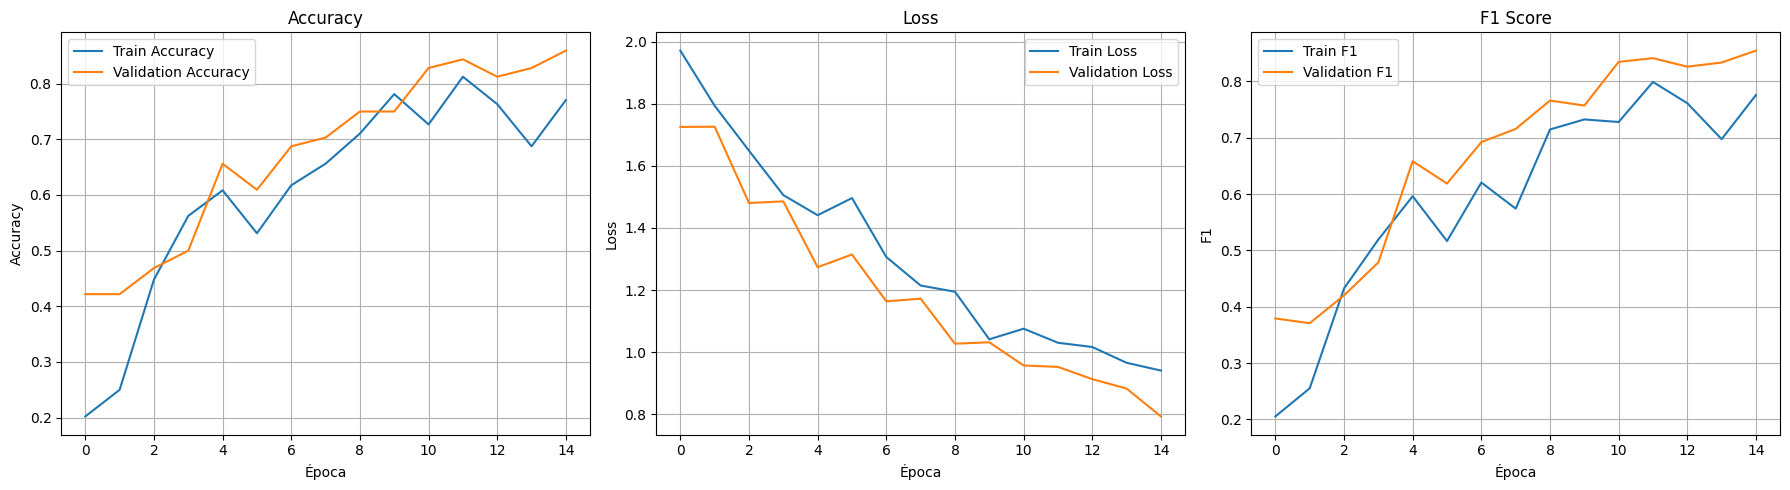

In [81]:
# Evaluar el modelo del paper con los datos de Test
paper_test_loss, paper_test_accuracy, paper_test_f1 = paper_model.evaluate(test_generator)

paper_test_f1_mean = np.mean(paper_test_f1)

print(f"Resultados del Modelo Paper (VGG-16):")
print(f"Test Loss: {paper_test_loss:.4f}")
print(f"Test Accuracy: {paper_test_accuracy:.4f}")
print(f"Test F1 score: {paper_test_f1_mean:.4f}")

# Graficar el historial del modelo del paper
plot_training_history(paper_history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step


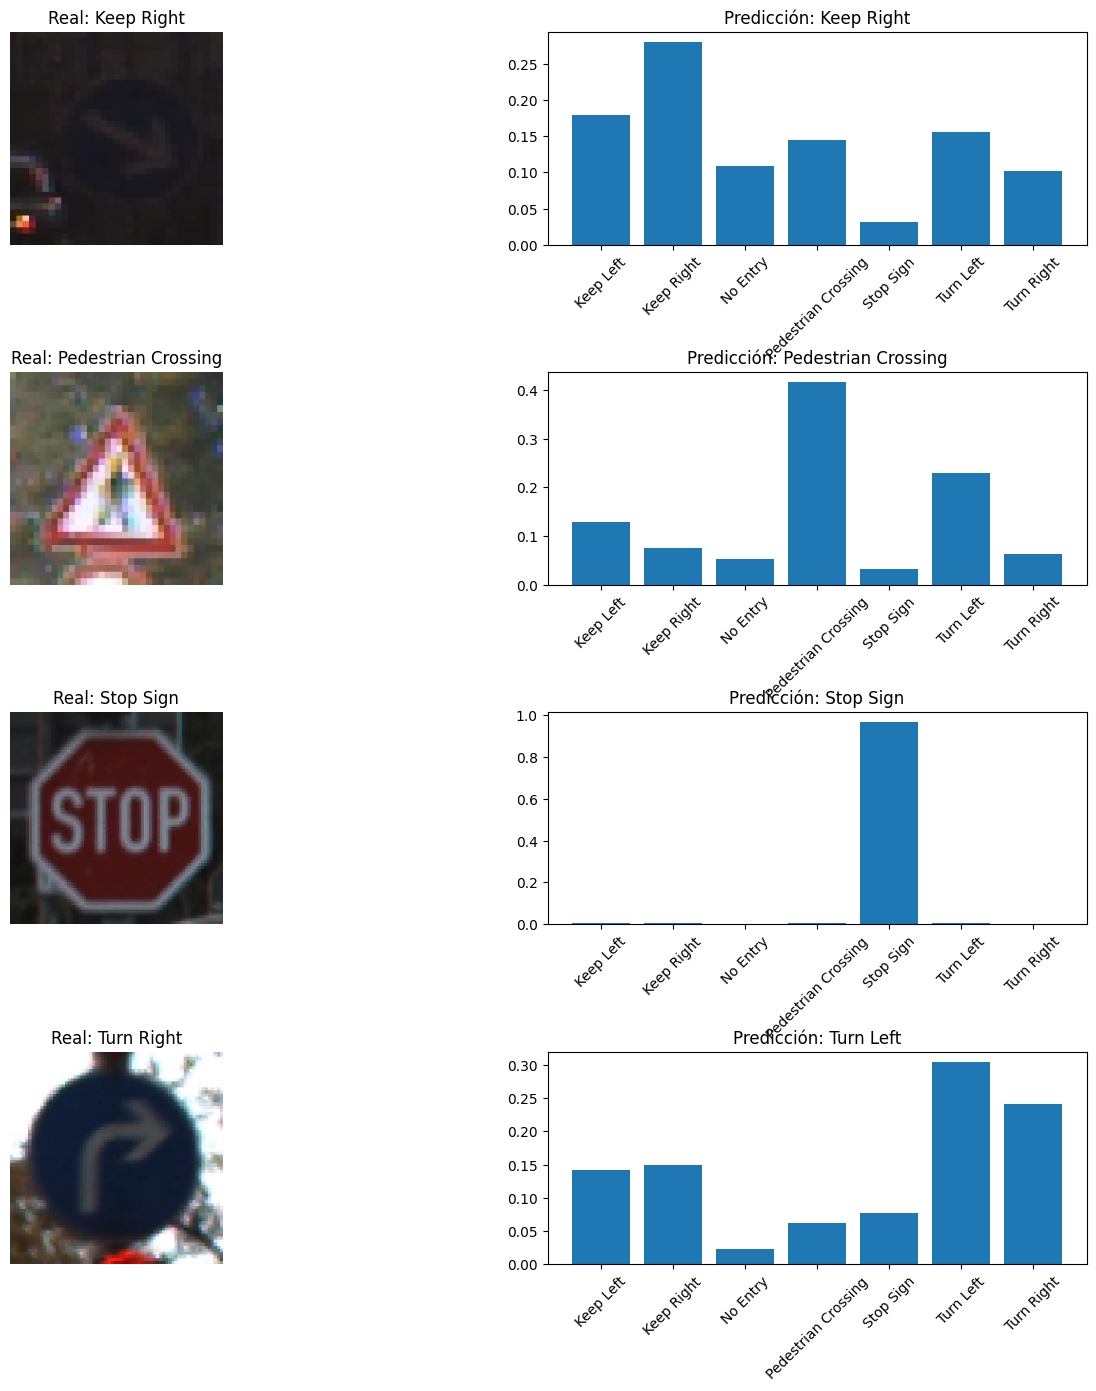

In [82]:
show_predictions(paper_model, test_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step


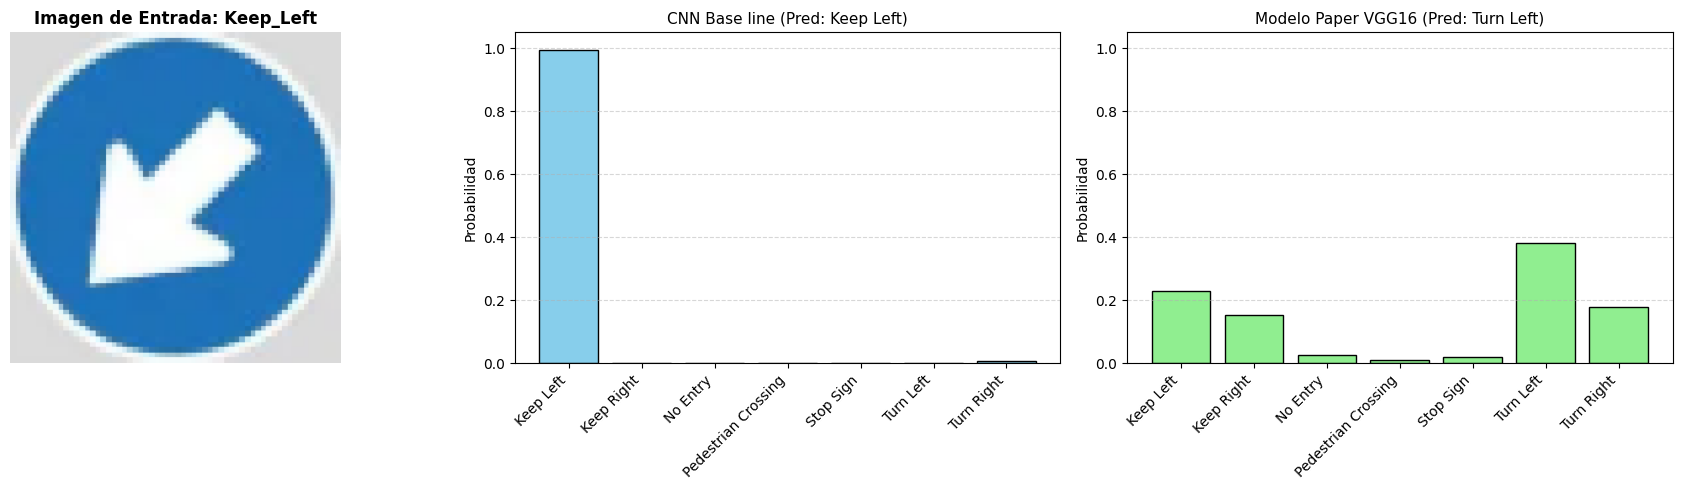

In [83]:
from tensorflow.keras.preprocessing import image

img_path = '/kaggle/input/datasets/axelcv10/myroadsignalsdataset/Keep_Left.png'
img = image.load_img(img_path, target_size=(224, 224))

x = image.img_to_array(img)
x = x / 255.0
x = np.expand_dims(x, axis=0)

preds_my_model = model.predict(x)          # Baseline
preds_paper_model = paper_model.predict(x)  # Modelo VGG-16 del paper

class_names = list(test_generator.class_indices.keys())
label_my_model = class_names[np.argmax(preds_my_model)]
label_paper_model = class_names[np.argmax(preds_paper_model)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
y_pos = np.arange(len(class_names))

axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title('Imagen de Entrada: Keep_Left', fontsize=12, fontweight='bold')

axes[1].bar(y_pos, preds_my_model[0], color='skyblue', edgecolor='black')
axes[1].set_xticks(y_pos)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].set_title(f'CNN Base line (Pred: {label_my_model})', fontsize=11)
axes[1].set_ylabel('Probabilidad')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

axes[2].bar(y_pos, preds_paper_model[0], color='lightgreen', edgecolor='black')
axes[2].set_xticks(y_pos)
axes[2].set_xticklabels(class_names, rotation=45, ha='right')
axes[2].set_title(f'Modelo Paper VGG16 (Pred: {label_paper_model})', fontsize=11)
axes[2].set_ylabel('Probabilidad')
axes[2].set_ylim(0, 1.05)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Guardar modelo del paper

In [84]:
paper_model.save('/kaggle/working/road_signs_model_paper.h5')

# Matríz de confusión

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def generar_matriz_confusion(modelo, nombre_modelo, generator, class_names):
    generator.shuffle = False
    generator.reset()
    
    y_true = np.array(generator.classes).astype(int)
    
    # Predicciones
    preds = modelo.predict(generator)
    if isinstance(preds, tuple): preds = preds[0]
    preds_limpias = np.squeeze(preds)
    y_pred = np.argmax(preds_limpias, axis=-1).astype(int)
    
    # Matriz
    cm = confusion_matrix(y_true, y_pred)
    
    # Graficar
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45, values_format='d')
    
    plt.title(f'Matriz de Confusión: {nombre_modelo}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

# Categorías
categorias = ['Keep Left', 'Keep Right', 'No Entry', 'Pedestrian Crossing', 
              'Stop Sign', 'Turn Left', 'Turn Right']

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


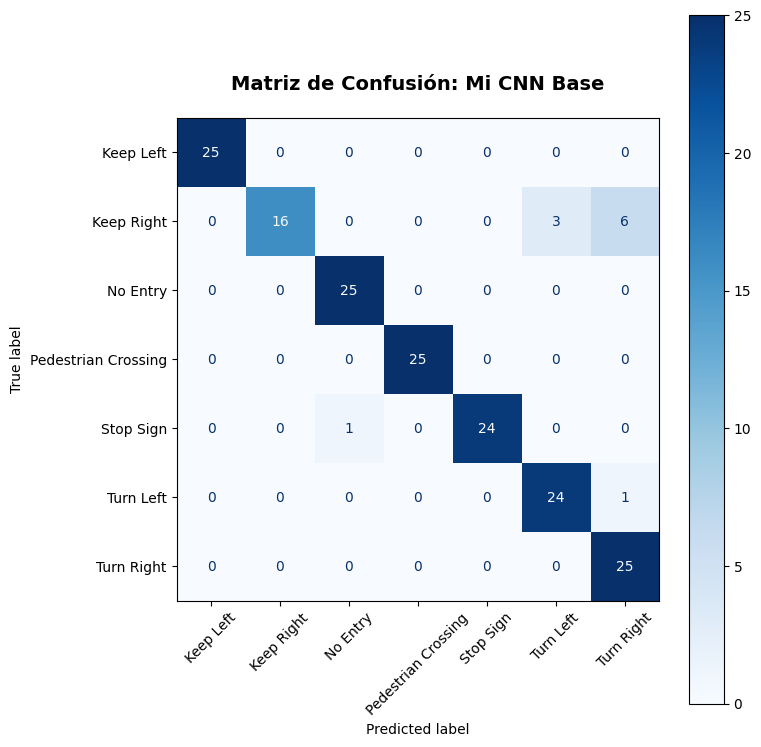

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


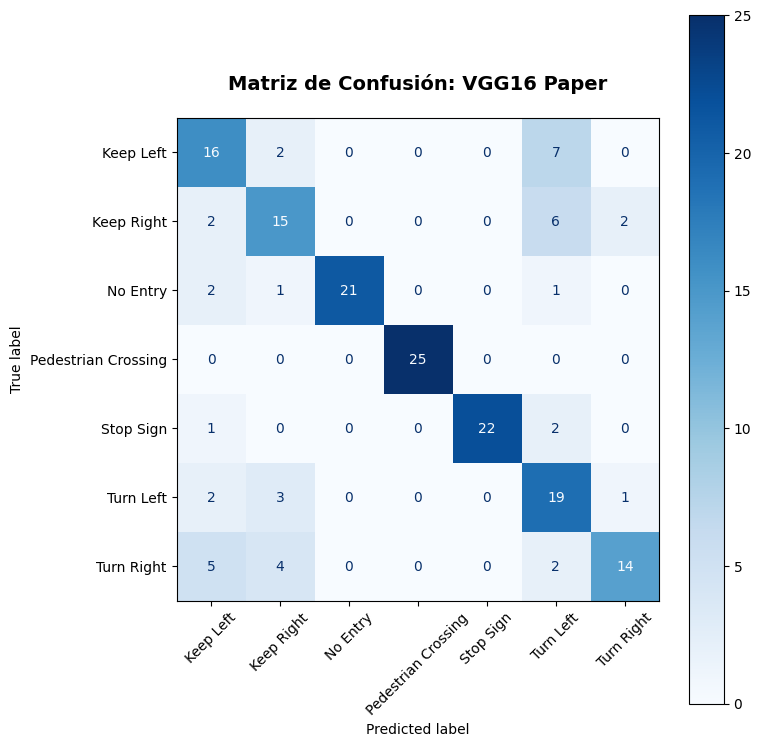

In [93]:
generar_matriz_confusion(model, "Mi CNN Base", test_generator, categorias)
generar_matriz_confusion(paper_model, "VGG16 Paper", test_generator, categorias)

# Propuesta de mejora
Uso de transfer learning

In [87]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

def get_vgg16_hybrid_model(input_shape=(224, 224, 3), num_classes=7):
    # Modelo base VGG16
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # FINE TUNING: Descongelar solo el último bloque convolucional (bloque 5)
    for layer in base_model.layers[:-4]:
        layer.trainable = False
    for layer in base_model.layers[-4:]:
        layer.trainable = True

    x = base_model.output
    x = Flatten()(x) 
    x = Dense(512, activation='relu')(x)
    
    # El Dropout ayuda a evitar que VGG16 memorice los datos
    x = Dropout(0.5)(x) 
    
    predictions = Dense(num_classes, activation='softmax')(x)

    hybrid_model = Model(inputs=base_model.input, outputs=predictions)
    
    hybrid_model.compile(optimizer=Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy', 'F1Score'])
    
    return hybrid_model

vgg16_hybrid_model = get_vgg16_hybrid_model()


hybrid_history = train_model(vgg16_hybrid_model, train_generator, validation_generator, epochs=30)

Epoch 1/30
 19/100 ━━━━━━━━━━━━━━━━━━━━ 34s 426ms/step - F1Score: 0.1497 - accuracy: 0.1743 - loss: 2.2310

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - F1Score: 0.2114 - accuracy: 0.2151 - loss: 2.0808 - val_F1Score: 0.5711 - val_accuracy: 0.5974 - val_loss: 1.5389
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - F1Score: 0.3233 - accuracy: 0.3322 - loss: 1.7539 - val_F1Score: 0.6846 - val_accuracy: 0.6753 - val_loss: 1.2457
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - F1Score: 0.4563 - accuracy: 0.4578 - loss: 1.4482 - val_F1Score: 0.7819 - val_accuracy: 0.7792 - val_loss: 0.9821
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - F1Score: 0.5789 - accuracy: 0.5818 - loss: 1.1166 - val_F1Score: 0.8621 - val_accuracy: 0.8571 - val_loss: 0.7288
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - F1Score: 0.7038 - accuracy: 0.7022 - loss: 0.8990 - val_F1Score: 0.9218 - val_accuracy: 0.9221 - val_loss: 0.5682
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - F1Score: 0.7520 - accuracy: 0.7556 - loss: 0.7384 - val_F1Score: 0.9229 - val_accuracy: 0.9221 - val_loss: 0.4

## Evaluar el modelo

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - F1Score: 0.9481 - accuracy: 0.9486 - loss: 0.0956
Resultados del modelo hybrido:
Test Loss: 0.0956
Test Accuracy: 0.9486
Test F1 score: 0.9481


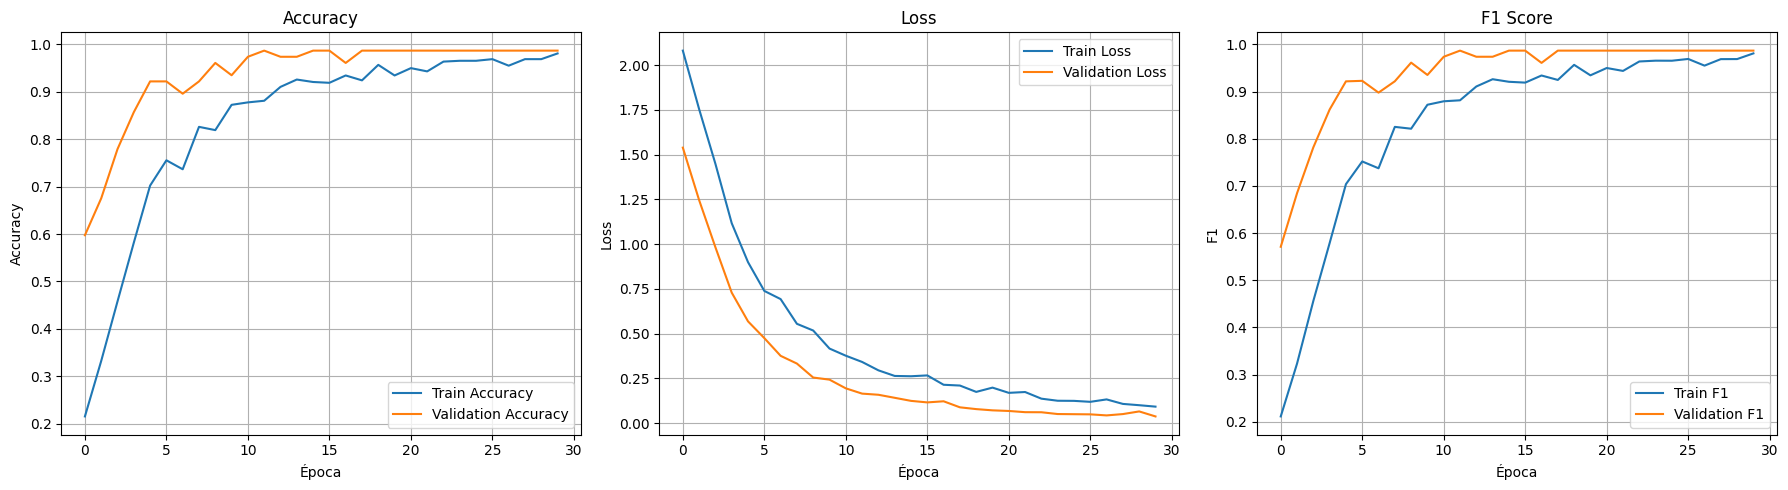

In [88]:
# Evaluar el modelo hibrido
vgg16_hybrid_test_loss, vgg16_hybrid_test_accuracy, vgg16_hybrid_test_f1 = vgg16_hybrid_model.evaluate(test_generator)

vgg16_hybrid_test_f1_mean = np.mean(vgg16_hybrid_test_f1)

print(f"Resultados del modelo hybrido:")
print(f"Test Loss: {vgg16_hybrid_test_loss:.4f}")
print(f"Test Accuracy: {vgg16_hybrid_test_accuracy:.4f}")
print(f"Test F1 score: {vgg16_hybrid_test_f1_mean:.4f}")

# Graficar el historial del modelo hibrido
plot_training_history(hybrid_history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step


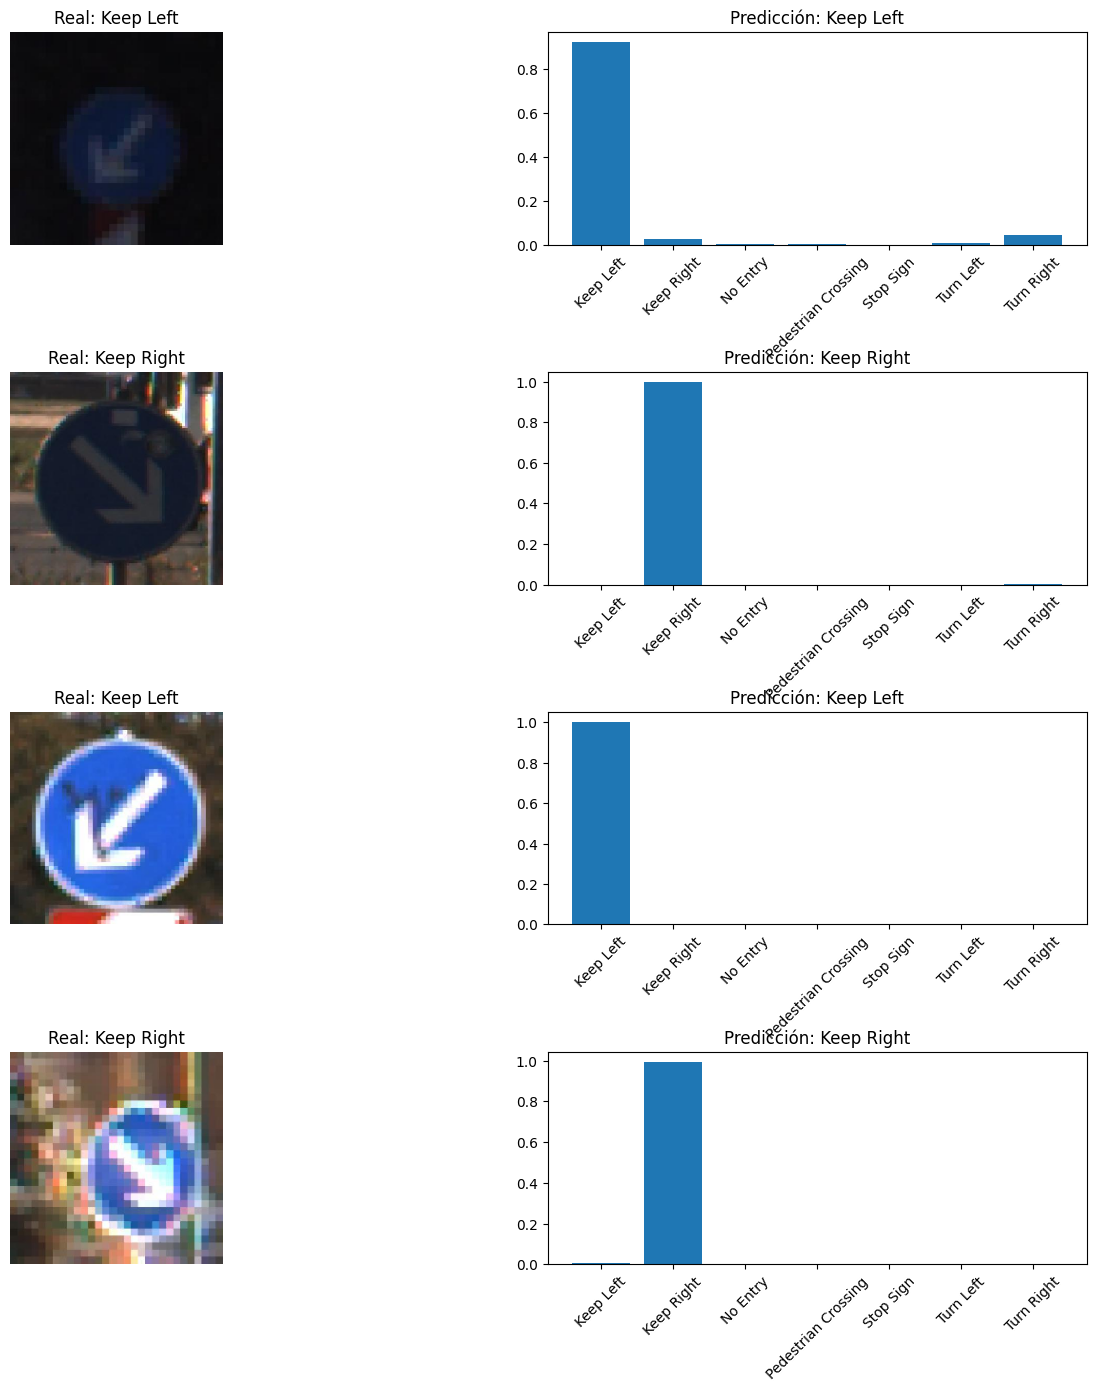

In [89]:
show_predictions(vgg16_hybrid_model, test_generator)

## Guardar el modelo hibrido

In [90]:
vgg16_hybrid_model.save('/kaggle/working/road_signs_model_hybrid.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step


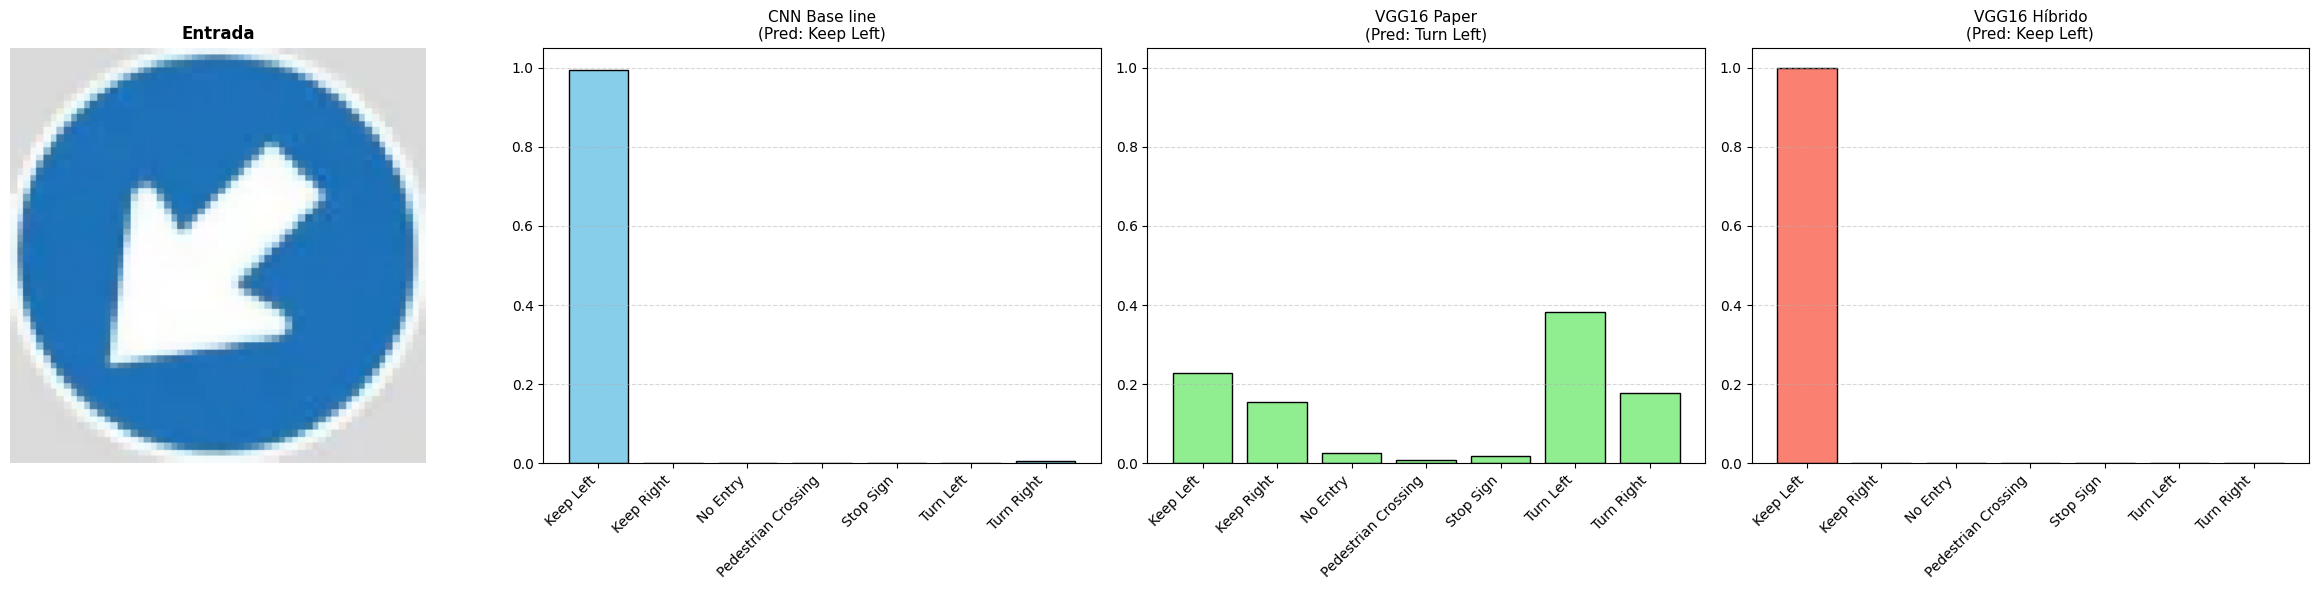

In [91]:
# Predicciones de los modelos
preds_my_model = model.predict(x)
preds_paper_model = paper_model.predict(x)
preds_hybrid_model = vgg16_hybrid_model.predict(x)

# Etiquetas
labels = [
    class_names[np.argmax(preds_my_model)],
    class_names[np.argmax(preds_paper_model)],
    class_names[np.argmax(preds_hybrid_model)]
]

# Configurar la figura (4 columnas: Imagen + 3 Modelos)
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
y_pos = np.arange(len(class_names))

# Imagen original
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title('Entrada', fontsize=12, fontweight='bold')

# Graficar los 3 modelos
modelos_preds = [preds_my_model, preds_paper_model, preds_hybrid_model]
colores = ['skyblue', 'lightgreen', 'salmon']
titulos = ['CNN Base line', 'VGG16 Paper', 'VGG16 Híbrido']

for i in range(3):
    axes[i+1].bar(y_pos, modelos_preds[i][0], color=colores[i], edgecolor='black')
    axes[i+1].set_xticks(y_pos)
    axes[i+1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[i+1].set_title(f'{titulos[i]}\n(Pred: {labels[i]})', fontsize=11)
    axes[i+1].set_ylim(0, 1.05)
    axes[i+1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


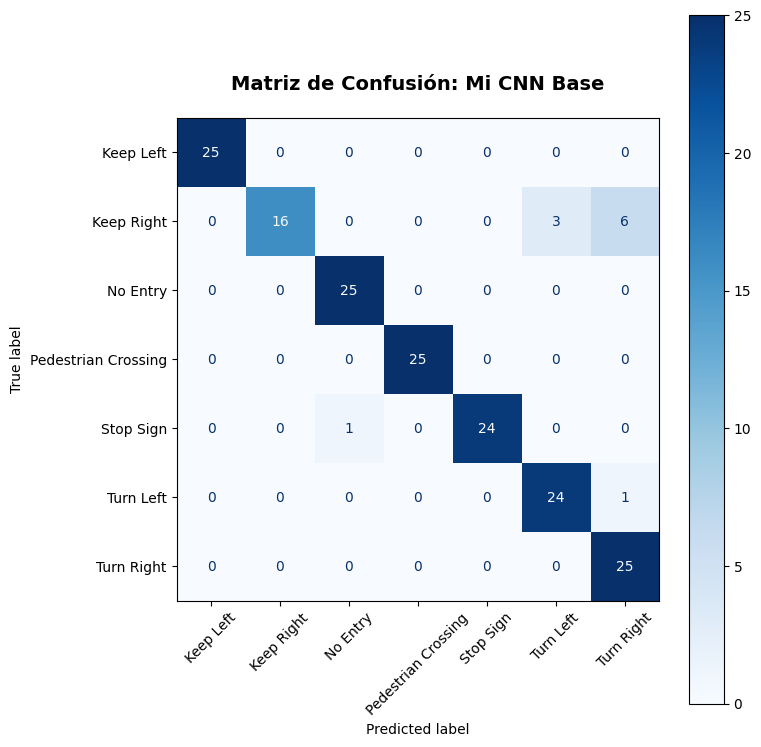

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


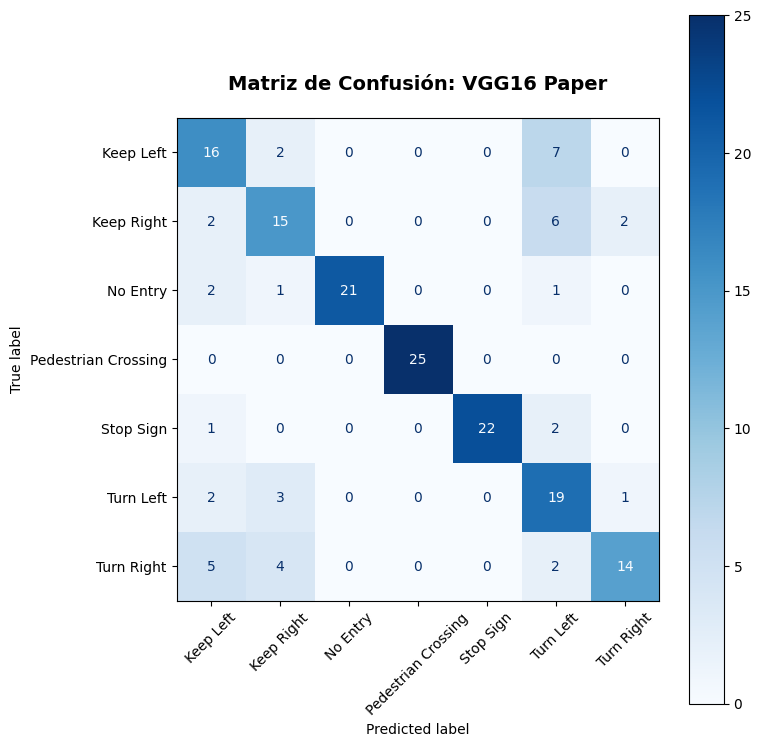

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step


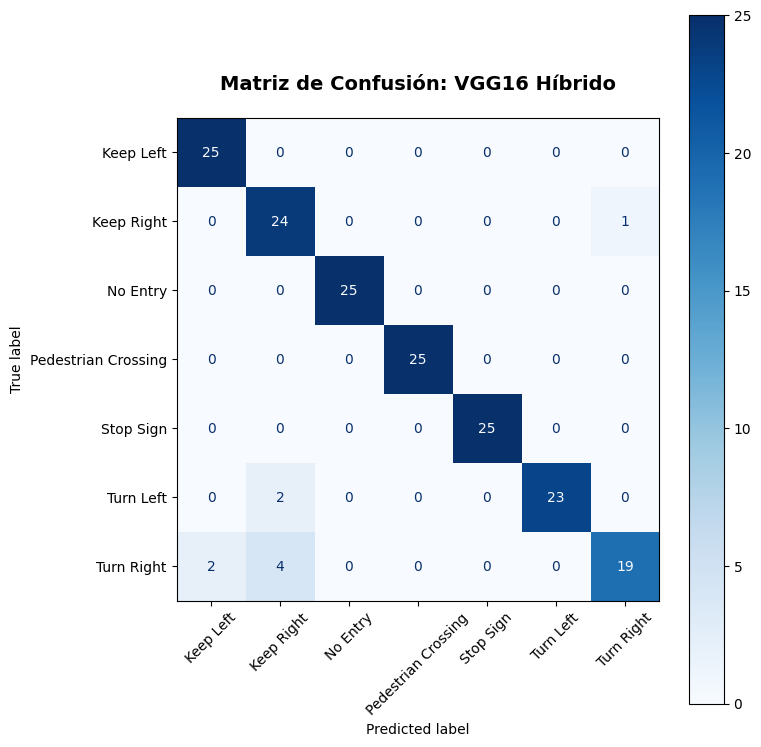

In [92]:
generar_matriz_confusion(model, "Mi CNN Base", test_generator, categorias)
generar_matriz_confusion(paper_model, "VGG16 Paper", test_generator, categorias)
generar_matriz_confusion(vgg16_hybrid_model, "VGG16 Híbrido", test_generator, categorias)